Keras example workflow

First we import all the necessary functions as usual

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import tensorflow_probability as tfp

Define the feature names, we are once again dealing with our wine dataset. We have 8 covariates in this case. 

Here is the explanation of the dataset from the repository:

Two datasets were created, using red and white wine samples. The inputs include objective tests (e.g. PH values) and the output is based on sensory data (median of at least 3 evaluations made by wine experts). Each expert graded the wine quality between 0 (very bad) and 10 (very excellent).

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009]. Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

Number of Instances: red wine - 1599; white wine - 4898

Input variables (based on physicochemical tests):

    fixed acidity
    volatile acidity
    citric acid
    residual sugar
    chlorides
    free sulfur dioxide
    total sulfur dioxide
    density
    pH
    sulphates
    alcohol

Output variable (based on sensory data):

    quality (score between 0 and 10)


In [2]:
FEATURE_NAMES = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]

Define our hidden units and learning rate. In this case we have an 8x8 matrix of hidden layers.

In [3]:
hidden_units = [8, 8]
learning_rate = 0.001

Create the helper function to deal w the inputs

In [4]:
def create_model_inputs():
    inputs = {}
    for feature_name in FEATURE_NAMES:
        inputs[feature_name] = layers.Input(
            name=feature_name, shape=(1,), dtype=tf.float32
        )
    return inputs

The helper function for splitting the dataset. 

In [5]:
def get_train_and_test_splits(train_size, batch_size=1):
    # We prefetch with a buffer the same size as the dataset because th dataset
    # is very small and fits into memory.
    dataset = (
        tfds.load(name="wine_quality", as_supervised=True, split="train")
        #convert to floating point
        .map(lambda x, y: (x, tf.cast(y, tf.float32)))
        .prefetch(buffer_size=dataset_size)
        .cache()
    )
    # We shuffle with a buffer the same size as the dataset.
    train_dataset = (
        dataset.take(train_size).shuffle(buffer_size=train_size).batch(batch_size)
    )
    test_dataset = dataset.skip(train_size).batch(batch_size)

    return train_dataset, test_dataset

Here is the helper function to execute our BNN. It has a model input, a loss function input, a training dataset input, and the test ddataset input. We also define what metrics we want to use to assess our model, in this case going with the classic Root Mean Squared Error

In [6]:
def run_experiment(model, loss, train_dataset, test_dataset):

    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=learning_rate),
        loss=loss,
        metrics=[keras.metrics.RootMeanSquaredError()],
    )

    print("Start training the model...")
    model.fit(train_dataset, epochs=num_epochs, validation_data=test_dataset)
    print("Model training finished.")
    _, rmse = model.evaluate(train_dataset, verbose=0)
    print(f"Train RMSE: {round(rmse, 3)}")

    print("Evaluating model performance...")
    _, rmse = model.evaluate(test_dataset, verbose=0)
    print(f"Test RMSE: {round(rmse, 3)}")

Here we set the parameters for a non-probabalistic approximately bayesian neural network. We also define our batch size, training size, and training dataset using the functions we built above. We also define our loss function in this case as MSE

In [8]:
dataset_size = 4898
batch_size = 256
num_epochs = 100
sample = 10
train_size = int(dataset_size * 0.85)

mse_loss = keras.losses.MeanSquaredError()

Use our data handling function to define our training set and test set
We also grab a random set of 10 predictions to see how we did.

In [9]:
# Split the datasets into two groups
train_dataset, test_dataset = get_train_and_test_splits(train_size, batch_size)

# Sample some example targets from the test dataset
examples, targets = list(test_dataset.unbatch().shuffle(batch_size * 10).batch(sample))[0]

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Next we get to define our prior and posterior. In this case we are using the classic multivariate normal.

In [10]:
def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = keras.Sequential(
        [
            tfp.layers.DistributionLambda(
                lambda t: tfp.distributions.MultivariateNormalDiag(
                    loc=tf.zeros(n), scale_diag=tf.ones(n)
                )
            )
        ]
    )
    return prior_model

In [11]:
def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    posterior_model = keras.Sequential(
        [
            tfp.layers.VariableLayer(
                tfp.layers.MultivariateNormalTriL.params_size(n), dtype=dtype
            ),
            tfp.layers.MultivariateNormalTriL(n),
        ]
    )
    return posterior_model

Here is the function that creates our first BNN. It takes in all the inputs we've created, and iterates over the hidden layers to produce the output. We use a sigmoid activation function and our multivariate normal prior. Since it doesn't give us probabilistic outputs, we are just using our prior as a form of regularization. 

In [12]:
def create_bnn_model(train_size):
    inputs = create_model_inputs()
    features = keras.layers.concatenate(list(inputs.values()))
    features = layers.BatchNormalization()(features)

    # Create hidden layers with weight uncertainty using the DenseVariational layer.
    for units in hidden_units:
        features = tfp.layers.DenseVariational(
            units=units,
            make_prior_fn=prior,
            make_posterior_fn=posterior,
            kl_weight=1 / train_size,
            activation="sigmoid",
        )(features)

    # The output is deterministic: a single point estimate.
    outputs = layers.Dense(units=1)(features)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

Finally, our prediction function for our first BNN. It creates an empty prediction vector, iterates over the sampled examples, calculates prediction mean, min, max, and range, and displays it all.

In [13]:
def compute_predictions(model, iterations=100):
    predicted = []
    for _ in range(iterations):
        predicted.append(model(examples).numpy())
    predicted = np.concatenate(predicted, axis=1)

    prediction_mean = np.mean(predicted, axis=1).tolist()
    prediction_min = np.min(predicted, axis=1).tolist()
    prediction_max = np.max(predicted, axis=1).tolist()
    prediction_range = (np.max(predicted, axis=1) - np.min(predicted, axis=1)).tolist()

    for idx in range(sample):
        print(
            f"Predictions mean: {round(prediction_mean[idx], 2)}, "
            f"min: {round(prediction_min[idx], 2)}, "
            f"max: {round(prediction_max[idx], 2)}, "
            f"range: {round(prediction_range[idx], 2)} - "
            f"Actual: {targets[idx]}"
        )

Now we get to actually run the model. For speed I've got 500 epochs. Then we use our experiment function with our model input, MSE loss, and our 85/15 training-test split.

In [14]:
num_epochs = 1000
bnn_model_full = create_bnn_model(train_size)
run_experiment(bnn_model_full, mse_loss, train_dataset, test_dataset)

Instructions for updating:
`scale_identity_multiplier` is deprecated; please combine it into `scale_diag` directly instead.


Instructions for updating:
`scale_identity_multiplier` is deprecated; please combine it into `scale_diag` directly instead.


Start training the model...
Epoch 1/500
17/17 [==============================] - 2s 30ms/step - loss: 38.3434 - root_mean_squared_error: 6.1918 - val_loss: 41.7296 - val_root_mean_squared_error: 6.4595
Epoch 2/500
17/17 [==============================] - 0s 3ms/step - loss: 36.9048 - root_mean_squared_error: 6.0746 - val_loss: 34.6280 - val_root_mean_squared_error: 5.8842
Epoch 3/500
17/17 [==============================] - 0s 3ms/step - loss: 36.4341 - root_mean_squared_error: 6.0357 - val_loss: 35.8727 - val_root_mean_squared_error: 5.9890
Epoch 4/500
17/17 [==============================] - 0s 3ms/step - loss: 34.6824 - root_mean_squared_error: 5.8888 - val_loss: 34.0625 - val_root_mean_squared_error: 5.8360
Epoch 5/500
17/17 [==============================] - 0s 3ms/step - loss: 34.0175 - root_mean_squared_error: 5.8321 - val_loss: 35.8917 - val_root_mean_squared_error: 5.9906
Epoch 6/500
17/17 [==============================] - 0s 2ms/step - loss: 32.3101 - root_mean_squared_error

Epoch 96/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6997 - root_mean_squared_error: 0.8303 - val_loss: 0.7065 - val_root_mean_squared_error: 0.8344
Epoch 97/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6765 - root_mean_squared_error: 0.8163 - val_loss: 0.7519 - val_root_mean_squared_error: 0.8618
Epoch 98/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6707 - root_mean_squared_error: 0.8126 - val_loss: 0.6757 - val_root_mean_squared_error: 0.8150
Epoch 99/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6712 - root_mean_squared_error: 0.8132 - val_loss: 0.6724 - val_root_mean_squared_error: 0.8135
Epoch 100/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6695 - root_mean_squared_error: 0.8118 - val_loss: 0.6624 - val_root_mean_squared_error: 0.8076
Epoch 101/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6770 - root_mean_squared_error: 0.8167 - val_loss: 0.6619 - va

17/17 [==============================] - 0s 2ms/step - loss: 0.6193 - root_mean_squared_error: 0.7792 - val_loss: 0.6065 - val_root_mean_squared_error: 0.7714
Epoch 191/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6208 - root_mean_squared_error: 0.7798 - val_loss: 0.6230 - val_root_mean_squared_error: 0.7819
Epoch 192/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6249 - root_mean_squared_error: 0.7825 - val_loss: 0.6265 - val_root_mean_squared_error: 0.7838
Epoch 193/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6289 - root_mean_squared_error: 0.7853 - val_loss: 0.6324 - val_root_mean_squared_error: 0.7877
Epoch 194/500
17/17 [==============================] - 0s 3ms/step - loss: 0.6318 - root_mean_squared_error: 0.7873 - val_loss: 0.6024 - val_root_mean_squared_error: 0.7685
Epoch 195/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6286 - root_mean_squared_error: 0.7851 - val_loss: 0.6114 - val_root_mea

17/17 [==============================] - 0s 2ms/step - loss: 0.6107 - root_mean_squared_error: 0.7729 - val_loss: 0.6043 - val_root_mean_squared_error: 0.7690
Epoch 285/500
17/17 [==============================] - 0s 2ms/step - loss: 0.5986 - root_mean_squared_error: 0.7654 - val_loss: 0.6080 - val_root_mean_squared_error: 0.7715
Epoch 286/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6113 - root_mean_squared_error: 0.7733 - val_loss: 0.5990 - val_root_mean_squared_error: 0.7651
Epoch 287/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6072 - root_mean_squared_error: 0.7706 - val_loss: 0.5897 - val_root_mean_squared_error: 0.7595
Epoch 288/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6085 - root_mean_squared_error: 0.7715 - val_loss: 0.5978 - val_root_mean_squared_error: 0.7652
Epoch 289/500
17/17 [==============================] - 0s 3ms/step - loss: 0.6076 - root_mean_squared_error: 0.7707 - val_loss: 0.6017 - val_root_mea

17/17 [==============================] - 0s 2ms/step - loss: 0.5965 - root_mean_squared_error: 0.7633 - val_loss: 0.6091 - val_root_mean_squared_error: 0.7709
Epoch 379/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6122 - root_mean_squared_error: 0.7736 - val_loss: 0.5887 - val_root_mean_squared_error: 0.7580
Epoch 380/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6034 - root_mean_squared_error: 0.7676 - val_loss: 0.5891 - val_root_mean_squared_error: 0.7580
Epoch 381/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6103 - root_mean_squared_error: 0.7724 - val_loss: 0.5906 - val_root_mean_squared_error: 0.7612
Epoch 382/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6117 - root_mean_squared_error: 0.7724 - val_loss: 0.5915 - val_root_mean_squared_error: 0.7601
Epoch 383/500
17/17 [==============================] - 0s 3ms/step - loss: 0.6092 - root_mean_squared_error: 0.7719 - val_loss: 0.5956 - val_root_mea

17/17 [==============================] - 0s 2ms/step - loss: 0.5922 - root_mean_squared_error: 0.7600 - val_loss: 0.5998 - val_root_mean_squared_error: 0.7653
Epoch 473/500
17/17 [==============================] - 0s 2ms/step - loss: 0.5983 - root_mean_squared_error: 0.7639 - val_loss: 0.5861 - val_root_mean_squared_error: 0.7564
Epoch 474/500
17/17 [==============================] - 0s 2ms/step - loss: 0.5942 - root_mean_squared_error: 0.7610 - val_loss: 0.6254 - val_root_mean_squared_error: 0.7822
Epoch 475/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6021 - root_mean_squared_error: 0.7663 - val_loss: 0.5915 - val_root_mean_squared_error: 0.7586
Epoch 476/500
17/17 [==============================] - 0s 2ms/step - loss: 0.6011 - root_mean_squared_error: 0.7660 - val_loss: 0.6151 - val_root_mean_squared_error: 0.7745
Epoch 477/500
17/17 [==============================] - 0s 2ms/step - loss: 0.5968 - root_mean_squared_error: 0.7632 - val_loss: 0.5874 - val_root_mea

In [15]:
compute_predictions(bnn_model_full)

Predictions mean: 6.05, min: 5.76, max: 6.36, range: 0.6 - Actual: 5.0
Predictions mean: 5.55, min: 5.1, max: 5.88, range: 0.77 - Actual: 4.0
Predictions mean: 5.77, min: 5.32, max: 6.13, range: 0.81 - Actual: 5.0
Predictions mean: 6.14, min: 5.78, max: 6.42, range: 0.64 - Actual: 7.0
Predictions mean: 6.55, min: 6.36, max: 6.66, range: 0.3 - Actual: 6.0
Predictions mean: 6.13, min: 5.79, max: 6.39, range: 0.61 - Actual: 5.0
Predictions mean: 5.5, min: 5.0, max: 6.05, range: 1.05 - Actual: 5.0
Predictions mean: 6.51, min: 6.35, max: 6.65, range: 0.3 - Actual: 6.0
Predictions mean: 5.49, min: 4.97, max: 5.98, range: 1.0 - Actual: 4.0
Predictions mean: 5.24, min: 4.87, max: 5.67, range: 0.79 - Actual: 6.0


In [16]:
def create_probablistic_bnn_model(train_size):
    inputs = create_model_inputs()
    features = keras.layers.concatenate(list(inputs.values()))
    features = layers.BatchNormalization()(features)

    # Create hidden layers with weight uncertainty using the DenseVariational layer.
    for units in hidden_units:
        features = tfp.layers.DenseVariational(
            units=units,
            make_prior_fn=prior,
            make_posterior_fn=posterior,
            kl_weight=1 / train_size,
            activation="sigmoid",
        )(features)

    # Create a probabilisticå output (Normal distribution), and use the `Dense` layer
    # to produce the parameters of the distribution.
    # We set units=2 to learn both the mean and the variance of the Normal distribution.
    distribution_params = layers.Dense(units=2)(features)
    outputs = tfp.layers.IndependentNormal(1)(distribution_params)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


Define our negative log likelihood loss function and run the next experiment

In [17]:
def negative_loglikelihood(targets, estimated_distribution):
    return -estimated_distribution.log_prob(targets)


num_epochs = 1000
prob_bnn_model = create_probablistic_bnn_model(train_size)
run_experiment(prob_bnn_model, negative_loglikelihood, train_dataset, test_dataset)

Start training the model...
Epoch 1/1000
17/17 [==============================] - 2s 27ms/step - loss: 25.5199 - root_mean_squared_error: 7.0966 - val_loss: 16.0585 - val_root_mean_squared_error: 6.6761
Epoch 2/1000
17/17 [==============================] - 0s 3ms/step - loss: 19.3526 - root_mean_squared_error: 7.0199 - val_loss: 15.6582 - val_root_mean_squared_error: 7.0946
Epoch 3/1000
17/17 [==============================] - 0s 3ms/step - loss: 16.6380 - root_mean_squared_error: 6.9422 - val_loss: 11.3344 - val_root_mean_squared_error: 6.8592
Epoch 4/1000
17/17 [==============================] - 0s 3ms/step - loss: 14.1096 - root_mean_squared_error: 6.8584 - val_loss: 13.7019 - val_root_mean_squared_error: 6.9409
Epoch 5/1000
17/17 [==============================] - 0s 2ms/step - loss: 14.1338 - root_mean_squared_error: 6.7520 - val_loss: 10.8294 - val_root_mean_squared_error: 6.6886
Epoch 6/1000
17/17 [==============================] - 0s 2ms/step - loss: 11.9894 - root_mean_squared

17/17 [==============================] - 0s 3ms/step - loss: 1.2539 - root_mean_squared_error: 1.1809 - val_loss: 1.2295 - val_root_mean_squared_error: 1.2123
Epoch 96/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.2562 - root_mean_squared_error: 1.1901 - val_loss: 1.2078 - val_root_mean_squared_error: 1.1427
Epoch 97/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.2591 - root_mean_squared_error: 1.1847 - val_loss: 1.2298 - val_root_mean_squared_error: 1.1989
Epoch 98/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.2388 - root_mean_squared_error: 1.1748 - val_loss: 1.2396 - val_root_mean_squared_error: 1.2052
Epoch 99/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.2304 - root_mean_squared_error: 1.1825 - val_loss: 1.2426 - val_root_mean_squared_error: 1.2319
Epoch 100/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.2441 - root_mean_squared_error: 1.1638 - val_loss: 1.2346 - val_root_me

17/17 [==============================] - 0s 2ms/step - loss: 1.2019 - root_mean_squared_error: 1.1001 - val_loss: 1.1881 - val_root_mean_squared_error: 1.0988
Epoch 190/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1781 - root_mean_squared_error: 1.1035 - val_loss: 1.1714 - val_root_mean_squared_error: 1.1109
Epoch 191/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1847 - root_mean_squared_error: 1.1085 - val_loss: 1.1859 - val_root_mean_squared_error: 1.0836
Epoch 192/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1930 - root_mean_squared_error: 1.1031 - val_loss: 1.1798 - val_root_mean_squared_error: 1.1089
Epoch 193/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1899 - root_mean_squared_error: 1.0977 - val_loss: 1.1592 - val_root_mean_squared_error: 1.1076
Epoch 194/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1816 - root_mean_squared_error: 1.1015 - val_loss: 1.1968 - val_roo

17/17 [==============================] - 0s 2ms/step - loss: 1.1741 - root_mean_squared_error: 1.0731 - val_loss: 1.1562 - val_root_mean_squared_error: 1.1087
Epoch 284/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1732 - root_mean_squared_error: 1.1111 - val_loss: 1.1719 - val_root_mean_squared_error: 1.1467
Epoch 285/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1625 - root_mean_squared_error: 1.1066 - val_loss: 1.1766 - val_root_mean_squared_error: 1.1351
Epoch 286/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1640 - root_mean_squared_error: 1.0669 - val_loss: 1.1805 - val_root_mean_squared_error: 1.0949
Epoch 287/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1674 - root_mean_squared_error: 1.0863 - val_loss: 1.1549 - val_root_mean_squared_error: 1.1065
Epoch 288/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1687 - root_mean_squared_error: 1.0965 - val_loss: 1.1926 - val_roo

17/17 [==============================] - 0s 2ms/step - loss: 1.1653 - root_mean_squared_error: 1.0833 - val_loss: 1.1679 - val_root_mean_squared_error: 1.0326
Epoch 378/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1583 - root_mean_squared_error: 1.0834 - val_loss: 1.1742 - val_root_mean_squared_error: 1.0980
Epoch 379/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1694 - root_mean_squared_error: 1.1055 - val_loss: 1.1643 - val_root_mean_squared_error: 1.0977
Epoch 380/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1697 - root_mean_squared_error: 1.0747 - val_loss: 1.1630 - val_root_mean_squared_error: 1.1087
Epoch 381/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1723 - root_mean_squared_error: 1.0979 - val_loss: 1.1623 - val_root_mean_squared_error: 1.1053
Epoch 382/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1657 - root_mean_squared_error: 1.0902 - val_loss: 1.1492 - val_roo

...

17/17 [==============================] - 0s 2ms/step - loss: 1.1644 - root_mean_squared_error: 1.0926 - val_loss: 1.1461 - val_root_mean_squared_error: 1.0715
Epoch 566/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1566 - root_mean_squared_error: 1.0705 - val_loss: 1.1625 - val_root_mean_squared_error: 1.0809
Epoch 567/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1646 - root_mean_squared_error: 1.0795 - val_loss: 1.1550 - val_root_mean_squared_error: 1.0858
Epoch 568/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1608 - root_mean_squared_error: 1.0798 - val_loss: 1.1637 - val_root_mean_squared_error: 1.0754
Epoch 569/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1569 - root_mean_squared_error: 1.0724 - val_loss: 1.1732 - val_root_mean_squared_error: 1.0658
Epoch 570/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1670 - root_mean_squared_error: 1.0704 - val_loss: 1.1470 - val_roo

17/17 [==============================] - 0s 3ms/step - loss: 1.1542 - root_mean_squared_error: 1.0776 - val_loss: 1.1495 - val_root_mean_squared_error: 1.0637
Epoch 660/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1538 - root_mean_squared_error: 1.0608 - val_loss: 1.1630 - val_root_mean_squared_error: 1.0707
Epoch 661/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1616 - root_mean_squared_error: 1.0798 - val_loss: 1.1578 - val_root_mean_squared_error: 1.0912
Epoch 662/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1610 - root_mean_squared_error: 1.0939 - val_loss: 1.1843 - val_root_mean_squared_error: 1.0637
Epoch 663/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1566 - root_mean_squared_error: 1.0475 - val_loss: 1.1627 - val_root_mean_squared_error: 1.0980
Epoch 664/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1562 - root_mean_squared_error: 1.0611 - val_loss: 1.1693 - val_roo

17/17 [==============================] - 0s 3ms/step - loss: 1.1613 - root_mean_squared_error: 1.0629 - val_loss: 1.1485 - val_root_mean_squared_error: 1.0680
Epoch 754/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1569 - root_mean_squared_error: 1.0752 - val_loss: 1.1654 - val_root_mean_squared_error: 1.0617
Epoch 755/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1544 - root_mean_squared_error: 1.0864 - val_loss: 1.1550 - val_root_mean_squared_error: 1.1007
Epoch 756/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1537 - root_mean_squared_error: 1.0691 - val_loss: 1.1550 - val_root_mean_squared_error: 1.0316
Epoch 757/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1639 - root_mean_squared_error: 1.0836 - val_loss: 1.1573 - val_root_mean_squared_error: 1.1095
Epoch 758/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1620 - root_mean_squared_error: 1.0596 - val_loss: 1.1549 - val_roo

17/17 [==============================] - 0s 3ms/step - loss: 1.1511 - root_mean_squared_error: 1.0899 - val_loss: 1.1498 - val_root_mean_squared_error: 1.0455
Epoch 848/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1638 - root_mean_squared_error: 1.0694 - val_loss: 1.1593 - val_root_mean_squared_error: 1.0735
Epoch 849/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1571 - root_mean_squared_error: 1.0932 - val_loss: 1.1778 - val_root_mean_squared_error: 1.0316
Epoch 850/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1491 - root_mean_squared_error: 1.0685 - val_loss: 1.1833 - val_root_mean_squared_error: 1.0875
Epoch 851/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1585 - root_mean_squared_error: 1.0647 - val_loss: 1.1617 - val_root_mean_squared_error: 1.0684
Epoch 852/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1466 - root_mean_squared_error: 1.0666 - val_loss: 1.1749 - val_roo

17/17 [==============================] - 0s 3ms/step - loss: 1.1531 - root_mean_squared_error: 1.0843 - val_loss: 1.1464 - val_root_mean_squared_error: 1.0943
Epoch 942/1000
17/17 [==============================] - 0s 2ms/step - loss: 1.1520 - root_mean_squared_error: 1.0605 - val_loss: 1.1396 - val_root_mean_squared_error: 1.1086
Epoch 943/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1524 - root_mean_squared_error: 1.0459 - val_loss: 1.1404 - val_root_mean_squared_error: 1.0582
Epoch 944/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1541 - root_mean_squared_error: 1.0767 - val_loss: 1.1594 - val_root_mean_squared_error: 1.1017
Epoch 945/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1491 - root_mean_squared_error: 1.0733 - val_loss: 1.1460 - val_root_mean_squared_error: 1.1150
Epoch 946/1000
17/17 [==============================] - 0s 3ms/step - loss: 1.1550 - root_mean_squared_error: 1.0716 - val_loss: 1.1606 - val_roo

Finally, define the prediction values we want to see and display them for a look at the results.

In [18]:
prediction_distribution = prob_bnn_model(examples)
prediction_mean = prediction_distribution.mean().numpy().tolist()
prediction_stdv = prediction_distribution.stddev().numpy()

# The 95% CI is computed as mean ± (1.96 * stdv)
upper = (prediction_mean + (1.96 * prediction_stdv)).tolist()
lower = (prediction_mean - (1.96 * prediction_stdv)).tolist()
prediction_stdv = prediction_stdv.tolist()

for idx in range(sample):
    print(
        f"Prediction mean: {round(prediction_mean[idx][0], 2)}, "
        f"stddev: {round(prediction_stdv[idx][0], 2)}, "
        f"95% CI: [{round(upper[idx][0], 2)} - {round(lower[idx][0], 2)}]"
        f" - Actual: {targets[idx]}"
    )


Prediction mean: 5.97, stddev: 0.75, 95% CI: [7.44 - 4.49] - Actual: 5.0
Prediction mean: 5.5, stddev: 0.71, 95% CI: [6.89 - 4.1] - Actual: 4.0
Prediction mean: 6.02, stddev: 0.75, 95% CI: [7.49 - 4.56] - Actual: 5.0
Prediction mean: 6.25, stddev: 0.8, 95% CI: [7.82 - 4.68] - Actual: 7.0
Prediction mean: 6.56, stddev: 0.84, 95% CI: [8.21 - 4.91] - Actual: 6.0
Prediction mean: 6.11, stddev: 0.78, 95% CI: [7.63 - 4.58] - Actual: 5.0
Prediction mean: 5.92, stddev: 0.73, 95% CI: [7.35 - 4.49] - Actual: 5.0
Prediction mean: 6.51, stddev: 0.83, 95% CI: [8.15 - 4.88] - Actual: 6.0
Prediction mean: 5.68, stddev: 0.71, 95% CI: [7.07 - 4.29] - Actual: 4.0
Prediction mean: 5.4, stddev: 0.7, 95% CI: [6.76 - 4.03] - Actual: 6.0


Pytorch example using the Iris dataset

In [20]:
import numpy as np
from sklearn import datasets

import torch
import torch.nn as nn
import torch.optim as optim

import torchbnn as bnn

import matplotlib.pyplot as plt

Get our data and split it into inputs and targets

In [21]:
iris = datasets.load_iris()

X = iris.data
Y = iris.target 
x, y = torch.from_numpy(X).float(), torch.from_numpy(Y).long()
print(x.shape, y.shape)

torch.Size([150, 4]) torch.Size([150])


Then define our model. Overall it is a simpler method. We've got an uninformed prior in this case.

In [22]:
model = nn.Sequential(
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=4, out_features=100),
    nn.ReLU(),
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=100, out_features=3),
)

We have two loss functions here- cross entropy and kullback liebler divergence. We use the popular adam optimizer.

In [23]:
ce_loss = nn.CrossEntropyLoss()
kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
kl_weight = 0.01

optimizer = optim.Adam(model.parameters(), lr=0.01)

Here we run the actual model

In [25]:
for step in range(3000):
    pre = model(x)
    ce = ce_loss(pre, y)
    kl = kl_loss(model)
    cost = ce + kl_weight*kl
    
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
    
_, predicted = torch.max(pre.data, 1)
total = y.size(0)
correct = (predicted == y).sum()
print('- Accuracy: %f %%' % (100 * float(correct) / total))
print('- CE : %2.2f, KL : %2.2f' % (ce.item(), kl.item()))

- Accuracy: 98.000000 %
- CE : 0.06, KL : 3.33


Finally, plot

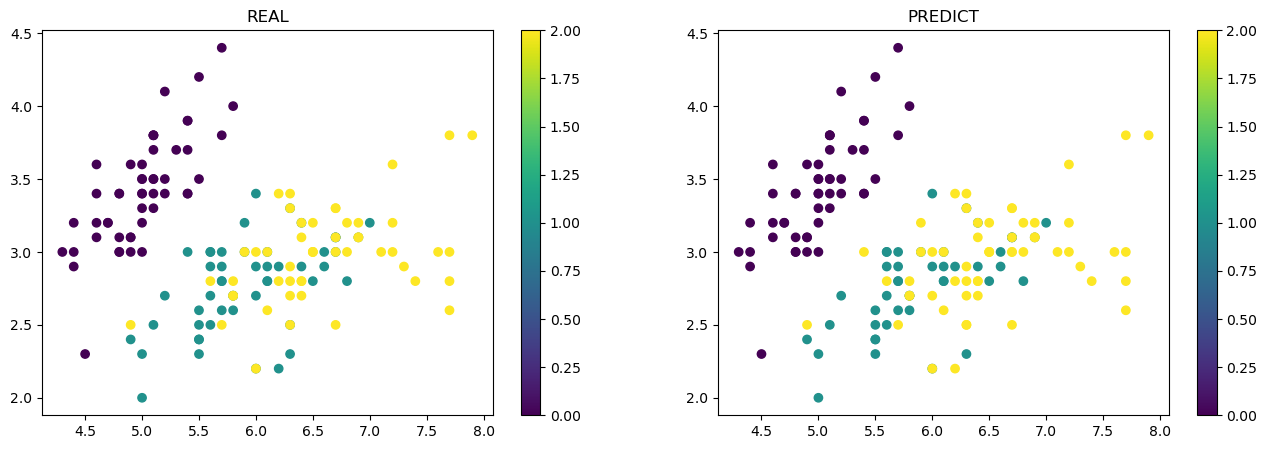

In [27]:
def draw_plot(predicted) :
    fig = plt.figure(figsize = (16, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)

    z1_plot = ax1.scatter(X[:, 0], X[:, 1], c = Y)
    z2_plot = ax2.scatter(X[:, 0], X[:, 1], c = predicted)

    plt.colorbar(z1_plot,ax=ax1)
    plt.colorbar(z2_plot,ax=ax2)

    ax1.set_title("REAL")
    ax2.set_title("PREDICT")

    plt.show()

pre = model(x)
_, predicted = torch.max(pre.data, 1)
draw_plot(predicted)

Next we will use pytorch for regression rather than classification

In [28]:
import numpy as np
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
import matplotlib.pyplot as plt

Here we generate our own data using a simulation.

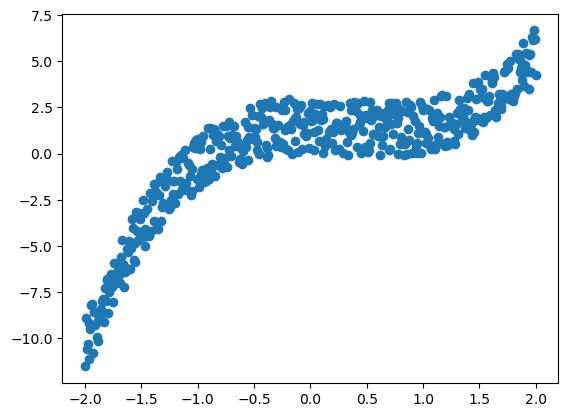

In [29]:
x = torch.linspace(-2, 2, 500)
y = x.pow(3) - x.pow(2) + 3*torch.rand(x.size())
x = torch.unsqueeze(x, dim=1)
y = torch.unsqueeze(y, dim=1)

plt.scatter(x.data.numpy(), y.data.numpy())
plt.show()

Once more with an uninformed prior

In [30]:
model = nn.Sequential(
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=1, out_features=100),
    nn.ReLU(),
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=100, out_features=1),
)

Same loss functions as above

In [31]:
mse_loss = nn.MSELoss()
kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
kl_weight = 0.1

optimizer = optim.Adam(model.parameters(), lr=0.01)

Iterate and fit the model

In [32]:
for step in range(3000):
    pre = model(x)
    mse = mse_loss(pre, y)
    kl = kl_loss(model)
    cost = mse + kl_weight*kl
    
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
    
print('- MSE : %2.2f, KL : %2.2f' % (mse.item(), kl.item()))

- MSE : 1.00, KL : 5.51


Simulate the test data

In [33]:
x_test = torch.linspace(-2, 2, 500)
y_test = x_test.pow(3) - x_test.pow(2) + 3*torch.rand(x_test.size())

x_test = torch.unsqueeze(x_test, dim=1)
y_test = torch.unsqueeze(y_test, dim=1)

Create some plots to visualize our predictions

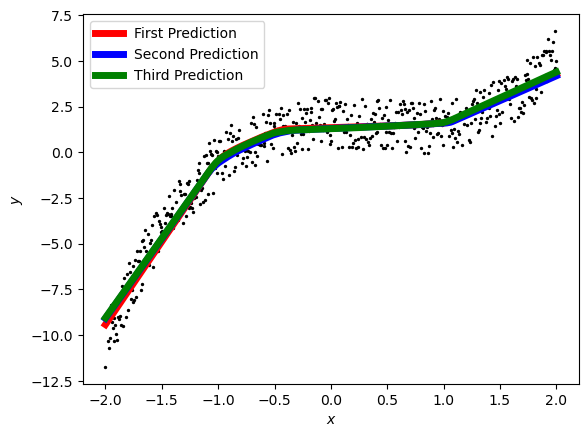

In [34]:
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.scatter(x_test.data.numpy(), y_test.data.numpy(), color='k', s=2) 

y_predict = model(x_test)
plt.plot(x_test.data.numpy(), y_predict.data.numpy(), 'r-', linewidth=5, label='First Prediction')

y_predict = model(x_test)
plt.plot(x_test.data.numpy(), y_predict.data.numpy(), 'b-', linewidth=5, label='Second Prediction')

y_predict = model(x_test)
plt.plot(x_test.data.numpy(), y_predict.data.numpy(), 'g-', linewidth=5, label='Third Prediction')

plt.legend()

plt.show()